###Resumo
O seguinte collab foi desenvolvido como um projeto avaliativo da maetria de fundamentos da inteligencia artificial.

O conjunto de codigos abaixo é responavel por relaziar a construção de um modelo ML de classificação de pacientes expostos à picadas de animais possivelmente pechonhetos.

---

###O dataset utilizado:
[`silent_sting_triage_data.csv`](https://www.kaggle.com/datasets/jacopoferretti/emergency-triage-venomous-bites-dataset)

---
###Membros do grupo:
*   Edno Bezerra Nascimento Junior
*   Nicolle Rillary Santana Silva
*   Wagner Kauê Martins dos Santos

---
## Recursos Necessários (atualizar dps)

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`, em formato de arquivo `.csv`.

---
### Instalação de dependências:

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn kagglehub pyarrow

---
### Imports das bibliotecas necessaria:

In [2]:
import numpy as np  #biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd #biblioteca usada para trabalhar com dataframes e análise de dados

# Geracao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Download do dataset
import kagglehub

# Pré-processamento e Validação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Utilidade
import os

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


/var/home/wk/.var/app/com.vscodium.codium/data/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Carregamento do dataset


In [ ]:
from logging import exception
import os

#tenta fazer o download do dataset
try:
  # Download do dataset
  path = kagglehub.dataset_download("jacopoferretti/emergency-triage-venomous-bites-dataset")

  csv_file_name = 'silent_sting_triage_data.csv'
  csv_file_path = os.path.join(path, csv_file_name)

  print("Download realizado, caminho para o dataset:", path)

except:
  #Se não consegue, muda o caminho para buscar o .Csv dos arquivos do notebook
  # Note: Windows path separator is '\\', Linux/macOS is '/'. Using os.path.join is safer.
  csv_file_path = os.path.join('dataset', 'silent_sting_triage_data.csv')
  print("Falha no download, buscando dataset em:", csv_file_path)

finally:
  # Converte o arquivo em um dataframe Panda
  # Prevent 'None' from being interpreted as NaN by default
  df = pd.read_csv(csv_file_path, sep=',', index_col=None, keep_default_na=False)
  # Visualizando as 5 primeiras linhas
  display(df.head())

100%|██████████| 13.8M/13.8M [00:01<00:00, 13.9MB/s]

Extracting files...


Download realizado, caminho para o dataset: /var/home/wk/.cache/kagglehub/datasets/jacopoferretti/emergency-triage-venomous-bites-dataset/versions/1


,Patient_ID,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,PAT_000000,56,Male,153,126,121,Mild,0,0,Scorpion
1,PAT_000001,19,Female,124,150,138,Mild,0,0,Scorpion
2,PAT_000002,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,PAT_000003,65,Male,143,139,144,Mild,0,0,Scorpion
4,PAT_000004,25,Female,195,87,98,Mild,0,0,Harmless_Insect


---
# Tratamento dos dados

###Limpeza de dados irrelevantes e verificação de dados nulos

In [4]:
# Remove a coluna Patient_ID pois não tem valor preditivo
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)

# Verificando se há valores nulos
print("\nVerificando valores nulos:")
print(df.isnull().sum())

# Verificando a distribuição das classes (tipos de picada)
print("\nDistribuição das classes (tipos de picada):")
print(df['Bite_Source_Target'].value_counts())


Verificando valores nulos:
Age                          0
Gender                       0
Time_Since_Bite_Min          0
Heart_Rate_BPM               0
Blood_Pressure_Systolic      0
Local_Swelling               0
Muscle_Paralysis_Present     0
Blood_Coagulation_Failure    0
Bite_Source_Target           0
dtype: int64

Distribuição das classes (tipos de picada):
Bite_Source_Target
Harmless_Insect       399623
Viper_Snake           299928
Scorpion              150292
Black_Widow_Spider    150157
Name: count, dtype: int64


### Valores duplicados ou incosistentes

Verifica a existencia de valores duplicados desconsiderando a coluna de classificação Bite_Source_Target

In [5]:
# Busca valores duplicados com base nas colunas 'Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'
df_duplicates = df[ df.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores duplicados, exibe
if len(df_duplicates)>0:
    print('\nAmostras redundantes:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


Amostras redundantes:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
506,43,Male,62,83,109,Mild,0,0,Harmless_Insect
751,65,Female,190,74,120,Mild,0,0,Harmless_Insect
975,10,Male,91,81,123,Mild,0,0,Harmless_Insect
1220,48,Male,139,87,124,Mild,0,0,Harmless_Insect
1493,50,Female,25,147,135,Mild,0,0,Scorpion
...,...,...,...,...,...,...,...,...,...
999039,30,Male,177,131,120,Mild,0,0,Scorpion
999255,38,Male,117,85,119,Mild,0,0,Harmless_Insect
999395,60,Male,34,88,116,Mild,0,0,Harmless_Insect
999615,67,Female,24,78,129,Mild,0,0,Harmless_Insect


Remove os valores duplicados de uma mesma classificação e mantendo apenas a primeira aparição

Realiza um novo teste de duplicatas para detecctar dados inconsistentes (entradas duplicadas com valores de classificação diferentes)

In [6]:
# Remove os valores duplicados deixando apenas a primeira ocorrencia
df = df.drop_duplicates(keep = 'first')


# Novo teste de valores duplicados
# Captura valores inconsistentes (entradas duplicadas com classificações diferentes)
df_duplicates = df[ df.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print('\nAmostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes')


Amostras inconsistentes:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
209228,6,Female,12,80,110,Mild,0,0,Scorpion
219397,28,Female,62,82,132,Mild,0,0,Harmless_Insect
220381,6,Female,12,80,110,Mild,0,0,Harmless_Insect
487733,28,Female,136,96,117,Mild,0,0,Scorpion
505569,28,Female,136,96,117,Mild,0,0,Harmless_Insect
527697,14,Female,222,90,108,Mild,0,0,Scorpion
686822,14,Female,222,90,108,Mild,0,0,Harmless_Insect
875419,28,Female,62,82,132,Mild,0,0,Scorpion


Remove todos os valores inconsistentes e realiza um novo teste de duplicatas apenas para garantir que os dados foram totalmente tratados

In [7]:
# Remove todos os valores incosistentes
df = df.drop_duplicates(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'], keep = False)

# Ultimo teste de valores duplicados\incosistentes
df_duplicates = df[ df.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print('\nAmostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes ou duplicados')

Não existem valores inconsistentes ou duplicados


### Dados não numericos

As colunas "Local_Swelling", "Gender" e "Bite_Source_Target" possuem valores do tipo String que devem ser tratados a fim de facilitar o processamento dos dados

In [8]:
# Create a copy to avoid modifying the original dataframe in place unexpectedly if run multiple times
# Or, ensure columns are present before processing

# 1. Variáveis Categóricas Preditoras (One-Hot Encoding)
# Check if 'Gender' and 'Local_Swelling' columns exist before processing
if 'Gender' in df.columns and 'Local_Swelling' in df.columns:
    df = pd.get_dummies(df, columns=['Gender', 'Local_Swelling'], drop_first=True)
elif 'Gender' in df.columns: # Handle cases where one might be missing but not the other
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
elif 'Local_Swelling' in df.columns:
    df = pd.get_dummies(df, columns=['Local_Swelling'], drop_first=True)

# 2. Variável Alvo (Label Encoding)
# Check if 'Bite_Source_Target' is still an object type before encoding
if 'Bite_Source_Target' in df.columns and df['Bite_Source_Target'].dtype == 'object':
    le = LabelEncoder()
    df['Bite_Source_Target'] = le.fit_transform(df['Bite_Source_Target'])

# Verificando como ficou o dataset após as transformações
display(df.head())

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
0,56,153,126,121,0,0,Scorpion,True,False,True,False,False
1,19,124,150,138,0,0,Scorpion,False,False,True,False,False
2,76,196,99,100,0,1,Viper_Snake,True,False,False,False,True
3,65,143,139,144,0,0,Scorpion,True,False,True,False,False
4,25,195,87,98,0,0,Harmless_Insect,False,False,True,False,False


### Separação de dados de treino e teste (20/80)


In [9]:
# Separando features (X) e target (y)
X = df.drop('Bite_Source_Target', axis=1)
y = df['Bite_Source_Target']

# Dividindo os dados em conjuntos de treino e teste (80/20) de forma estratificada
# A estratificação garante que a proporção de cada classe em 'y' seja a mesma nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

# Verificar a distribuição das classes nos conjuntos de treino e teste
print("\nDistribuição das classes em y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição das classes em y_test:")
print(y_test.value_counts(normalize=True))

Tamanho do conjunto de treino (X_train): (797736, 11)
Tamanho do conjunto de teste (X_test): (199434, 11)
Tamanho do conjunto de treino (y_train): (797736,)
Tamanho do conjunto de teste (y_test): (199434,)

Distribuição das classes em y_train:
Bite_Source_Target
Harmless_Insect       0.398682
Viper_Snake           0.300231
Scorpion              0.150633
Black_Widow_Spider    0.150455
Name: proportion, dtype: float64

Distribuição das classes em y_test:
Bite_Source_Target
Harmless_Insect       0.398683
Viper_Snake           0.300230
Scorpion              0.150631
Black_Widow_Spider    0.150456
Name: proportion, dtype: float64


### Normalização

In [10]:
# apresenta as principais estatísticas da base de dados de treinamento
df_detalhes = X_train.describe()

display(df_detalhes.round(8))

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,44.461193,124.387816,105.049305,117.303164,0.143346,0.253490
std,23.085763,66.364376,27.062013,24.529121,0.350425,0.435009
min,5.000000,10.000000,42.000000,39.000000,0.000000,0.000000
25%,24.000000,67.000000,82.000000,99.000000,0.000000,0.000000
50%,44.000000,124.000000,102.000000,118.000000,0.000000,0.000000
75%,64.000000,182.000000,124.000000,133.000000,0.000000,1.000000
max,84.000000,239.000000,243.000000,223.000000,1.000000,1.000000


In [11]:
# Inicializa o normalizador (Média 0 e Desvio Padrão 1)
scaler = StandardScaler()

# Lista das colunas numéricas que precisam de ajuste
colunas_numericas = ['Age', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic']

# Cria uma copia normalizada dos dados
X_train_Normalizado = X_train.copy()

# Normaliza as colunas numéricas
X_train_Normalizado[colunas_numericas] = scaler.fit_transform(X_train_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatisticas
display(X_train_Normalizado.head())
print('\n')
display(X_train_Normalizado.describe().round(8))

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
393316,-0.106611,1.003735,0.441604,0.762231,0,0,True,False,True,False,False
852561,0.629774,-1.271584,-0.740866,-0.053127,0,0,True,False,True,False,False
611780,-1.059580,-0.216800,0.330748,-0.868485,0,1,False,False,False,False,True
191771,1.019625,1.139350,-0.925627,-0.256967,0,0,False,False,True,False,False
412650,-1.449431,1.169486,-1.184292,0.476855,0,0,True,False,True,False,False


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,0.000000,-0.000000,0.000000,-0.000000,0.143346,0.253490
std,1.000001,1.000001,1.000001,1.000001,0.350425,0.435009
min,-1.709331,-1.723634,-2.329810,-3.192255,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.846358,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,5.097580,4.309038,1.000000,1.000000


In [12]:
# Cria uma copia normalizada dos dados de teste
X_test_Normalizado = X_test.copy()

# Aplica a normalização nas colunas numéricas do conjunto de teste
# IMPORTANTE: Usamos APENAS 'transform' com o scaler já ajustado em X_train
X_test_Normalizado[colunas_numericas] = scaler.transform(X_test_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatísticas
print("X_test normalizado (primeiras 5 linhas):")
display(X_test_Normalizado.head())
print('\nEstatísticas descritivas de X_test normalizado:')
display(X_test_Normalizado.describe().round(8))

X_test normalizado (primeiras 5 linhas):


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
539800,0.759724,-1.663361,-1.221244,0.232248,0,0,False,False,True,False,False
155569,0.456507,0.822915,0.478557,1.536821,1,0,False,False,False,True,False
915850,-1.666015,-0.337347,0.293796,-0.623878,0,1,False,False,False,False,True
139817,1.279526,1.651673,-0.814770,-0.053127,0,0,True,False,True,False,False
857484,0.976308,-1.377062,1.771883,1.740660,0,0,False,False,True,False,False



Estatísticas descritivas de X_test normalizado:


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000
mean,0.002105,-0.000279,0.000710,-0.002886,0.143286,0.253106
std,1.002363,1.000590,1.001158,0.998409,0.350365,0.434792
min,-1.709331,-1.723634,-2.403714,-3.355327,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.889675,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,4.691106,3.656751,1.000000,1.000000


### Analise de *outliers*

Utilizando uma representação grafica dos dados de treinamento é possivel analisar a distribuição numerica e analisar a presença de outliers



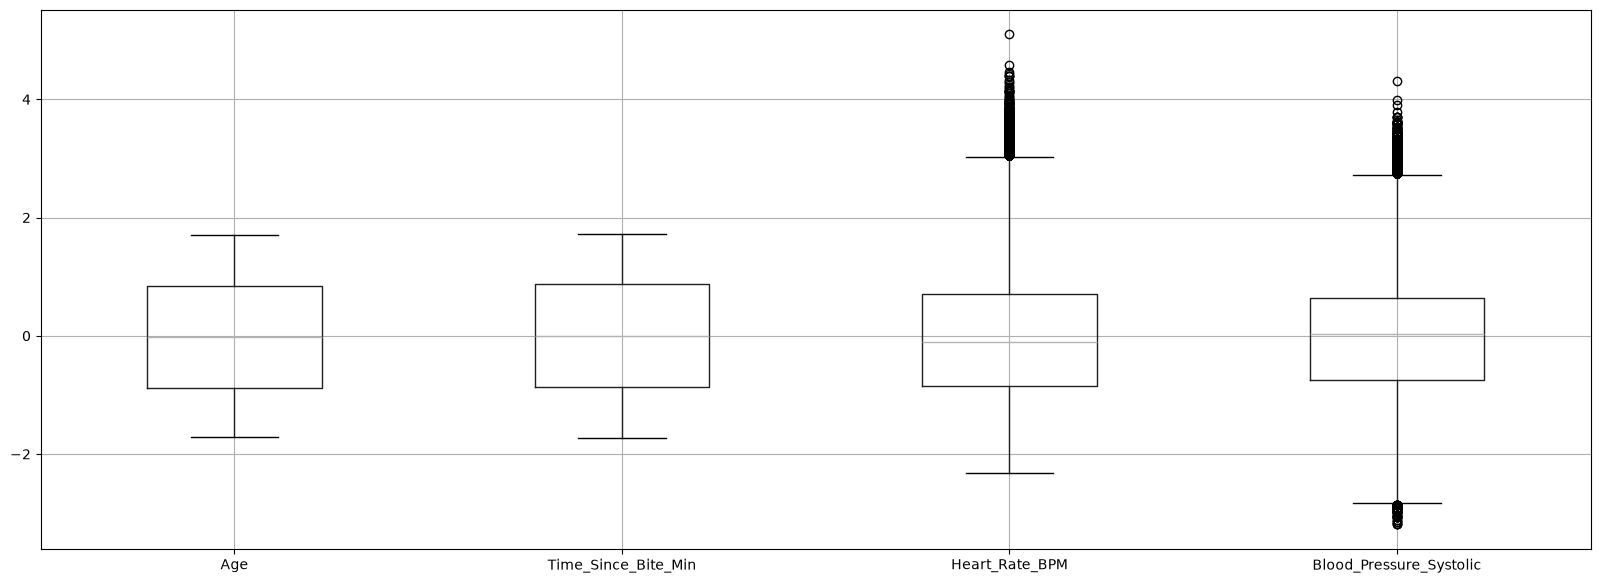

In [13]:
X_train_Normalizado[colunas_numericas].boxplot(figsize=(20,7))
plt.show()

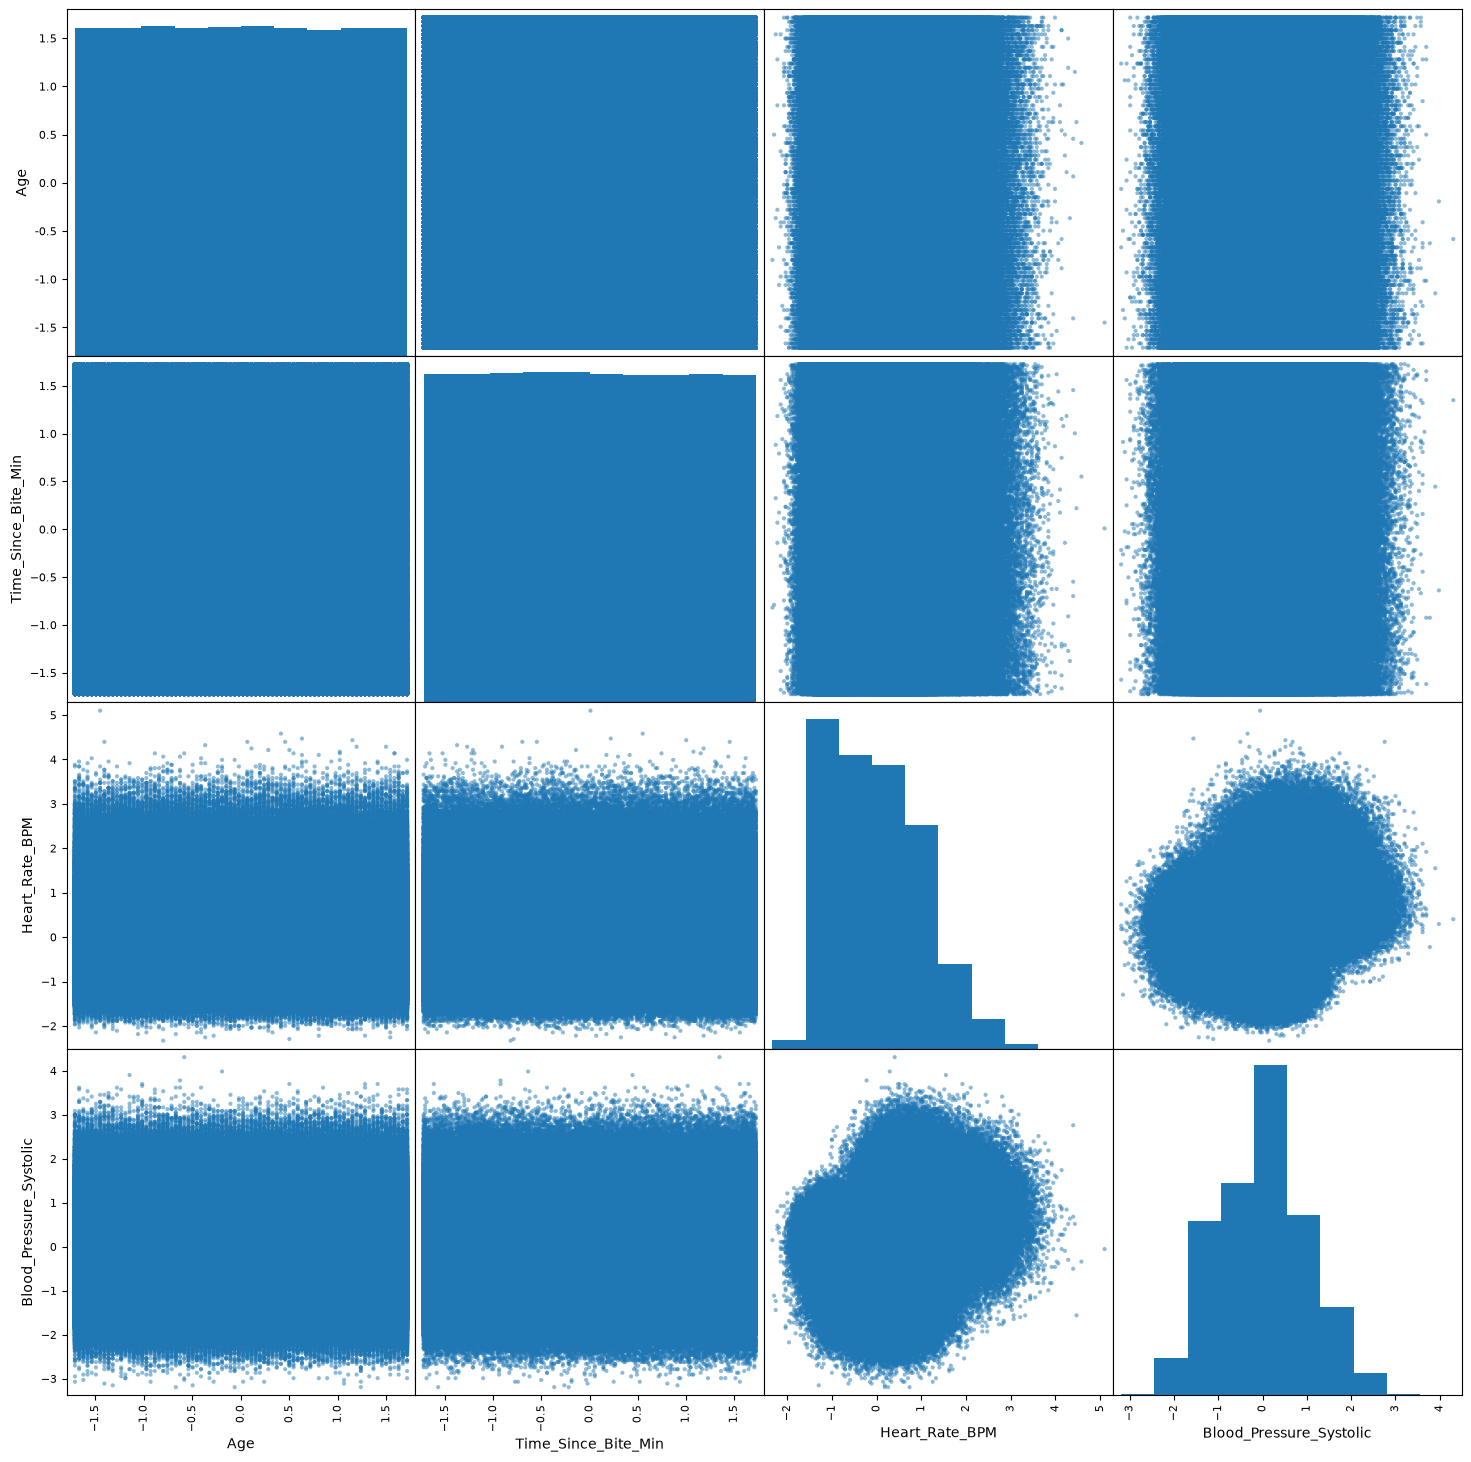

In [14]:
pd.plotting.scatter_matrix(X_train_Normalizado[colunas_numericas], figsize=(18,18))

plt.show()

A analise grafica dos dados numericos revela a presença de outliers nas colunas "Heart_rate_bpm" e "Blood_presure_sistolic". Porém, tais outliers não parecem ligados à erros de medição e representam dados importante para o diagnostico de estado geral do paceiente. Taxas elevadas de batimentos cardiacos podem indicar problemas cardiacos ligados à efeitos de neurotoxinas por exemplo, logo esses dados não devem ser removidos

## Treinamento dos modelos